## Environment Setup

In [2]:
!pip install torch torchvision
!pip install transformers
!pip install openai-whisper
!pip install opencv-python
!pip install librosa
!pip install faiss-cpu
!pip install jiwer
!pip install scikit-learn
!pip install datasets
!pip install accelerate
!pip install soundfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 47.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for openai-whisper: filename=openai_whisper-20250625-py3-none-any.whl size=803979 sha256=147739a56472efcc4f9b1dbd0585124187b0b8601d63381ddbb686d4f40f655e
  Stored in directory: /root/.cache/pip/wheels/61/d2/20/09ec9bef734d126cba375b15898010b6cc28578d8afdde5869
Successfully built openai-whisper
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 91.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 74.0 MB/s eta 0:00:00


## Import Libraries

In [3]:
import os
import json
import pickle
import zipfile
import shutil
import cv2
import torch
import whisper
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from transformers import (
    CLIPProcessor,
    CLIPModel,
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset
from jiwer import wer

## Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROJECT_PATH = "/content/drive/MyDrive/Smart_Campus_Multimodal_AI_Assistant"
print("Project path set to:", PROJECT_PATH)

Project path set to: /content/drive/MyDrive/Smart_Campus_Multimodal_AI_Assistant


### Unzip Dataset

In [6]:
zip_path = PROJECT_PATH + "/Smart_Campus_Multimodal_AI_Assistant.zip"
extract_path = PROJECT_PATH

if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Zip file not found. Assuming dataset is already extracted.")

Zip file not found. Assuming dataset is already extracted.


## Data Acquisition and Exploration

### Image Dataset Analysis

In [7]:
image_path = PROJECT_PATH + "/dataset/images"
classes = [c for c in os.listdir(image_path) if os.path.isdir(os.path.join(image_path, c))]
counts = {}
for c in classes:
    counts[c] = len(os.listdir(os.path.join(image_path, c)))
print("Classes found:", list(counts.keys()))
print("Image counts:", counts)

Classes found: ['lobby', 'waitingroom', 'office', 'stairscase', 'museum', 'restaurant_kitchen', 'meeting_room', 'locker_room', 'studiomusic', 'library', 'elevator', 'laboratorywet', 'gym', 'dining_room', 'classroom', 'corridor', 'auditorium', 'artstudio', 'bookstore']
Image counts: {'lobby': 101, 'waitingroom': 151, 'office': 109, 'stairscase': 155, 'museum': 168, 'restaurant_kitchen': 107, 'meeting_room': 233, 'locker_room': 249, 'studiomusic': 108, 'library': 107, 'elevator': 101, 'laboratorywet': 125, 'gym': 231, 'dining_room': 274, 'classroom': 113, 'corridor': 346, 'auditorium': 176, 'artstudio': 140, 'bookstore': 380}


### Campus Image Class Distribution

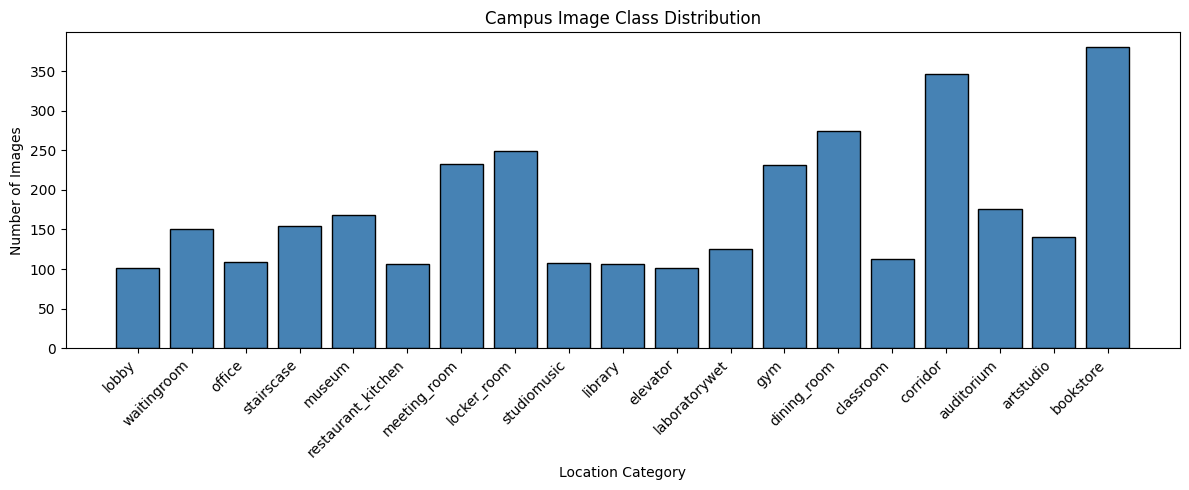

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title("Campus Image Class Distribution")
plt.xlabel("Location Category")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.savefig(PROJECT_PATH + "/class_distribution.png", dpi=150)
plt.show()

### Sample Image Display

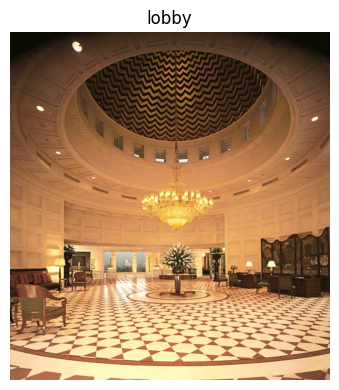

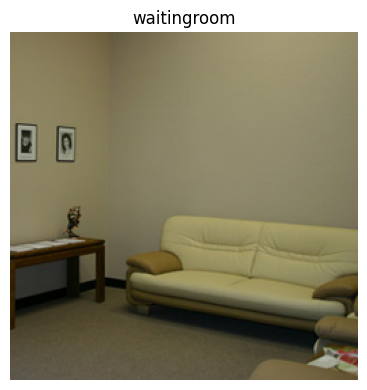

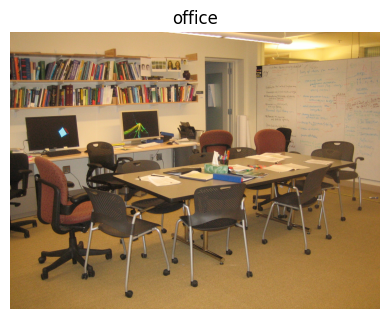

In [9]:
for folder in classes[:3]:
    folder_path = os.path.join(image_path, folder)
    img_file = os.listdir(folder_path)[0]
    img = cv2.imread(os.path.join(folder_path, img_file))
    plt.figure(figsize=(4, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(folder)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

### Voice and Text Data Exploration

Audio intent counts: {'ask_hours': 15, 'find_event': 10, 'find_location': 20, 'ask_direction': 15}


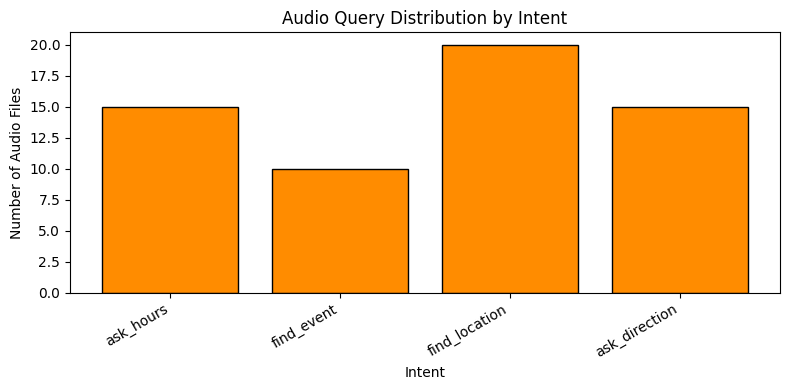

In [10]:
audio_base = PROJECT_PATH + "/dataset/audio"
intent_folders = os.listdir(audio_base)
audio_counts = {}
for intent in intent_folders:
    intent_path = os.path.join(audio_base, intent)
    if os.path.isdir(intent_path):
        audio_counts[intent] = len(os.listdir(intent_path))
print("Audio intent counts:", audio_counts)

plt.figure(figsize=(8, 4))
plt.bar(audio_counts.keys(), audio_counts.values(), color='darkorange', edgecolor='black')
plt.title("Audio Query Distribution by Intent")
plt.xlabel("Intent")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [11]:
faq = pd.read_csv(PROJECT_PATH + "/dataset/text/campus_queries.csv")
print("Shape:", faq.shape)
print(faq.head(10))

Shape: (200, 3)
                                    query         intent      location
0         Is the waiting room open today?      ask_hours  waiting room
1    Tell me opening hours of auditorium.      ask_hours    auditorium
2        Are there workshops at elevator?     find_event      elevator
3    What time does the dining room open?      ask_hours   dining room
4  Find programs happening in auditorium.     find_event    auditorium
5       Where can I access the staircase?  find_location     staircase
6   What time does the meeting room open?      ask_hours  meeting room
7      Where can I access the laboratory?  find_location    laboratory
8            Navigate me to waiting room.  ask_direction  waiting room
9         What time does the museum open?      ask_hours        museum


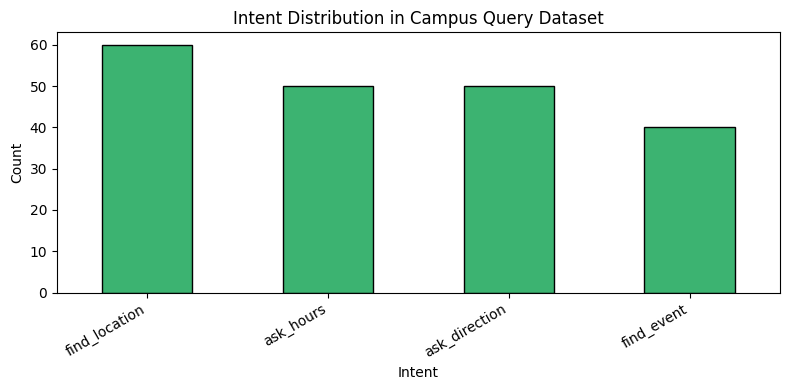

In [12]:
faq['intent'].value_counts().plot(kind='bar', figsize=(8, 4), color='mediumseagreen', edgecolor='black')
plt.title("Intent Distribution in Campus Query Dataset")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Campus Knowledge Base

In [13]:
kb = json.load(open(PROJECT_PATH + "/dataset/knowledge_base/campus_database.json"))
print(f"Total knowledge base records: {len(kb)}")
for rec in kb[:3]:
    print(json.dumps(rec, indent=2))

Total knowledge base records: 20
{
  "id": 1,
  "building_name": "Main Library",
  "folder_name": "library",
  "category": "Library",
  "description": "A quiet study facility providing books, computers, digital resources and research support.",
  "opening_hours": "08:00 AM - 09:00 PM",
  "map_reference": "Block A - Floor 2",
  "events": "Academic writing workshop every Monday"
}
{
  "id": 2,
  "building_name": "Lecture Classroom",
  "folder_name": "classroom",
  "category": "Lecture Hall",
  "description": "Teaching space equipped with smart boards and multimedia learning systems.",
  "opening_hours": "08:00 AM - 07:00 PM",
  "map_reference": "Block B - Floor 1",
  "events": "Guest lectures every Friday"
}
{
  "id": 3,
  "building_name": "Computer Laboratory",
  "folder_name": "computerroom",
  "category": "Computer Lab",
  "description": "Computer facility providing programming, AI and software development resources.",
  "opening_hours": "08:30 AM - 08:00 PM",
  "map_reference": "Bloc

## Preprocessing

### Image Preprocessing Pipeline

In [14]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=image_path, transform=image_transform)
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

Classes: ['artstudio', 'auditorium', 'bookstore', 'classroom', 'corridor', 'dining_room', 'elevator', 'gym', 'laboratorywet', 'library', 'lobby', 'locker_room', 'meeting_room', 'museum', 'office', 'restaurant_kitchen', 'stairscase', 'studiomusic', 'waitingroom']
Total images: 3374
Train: 2699 | Val: 675


### Sample Preprocessed Images

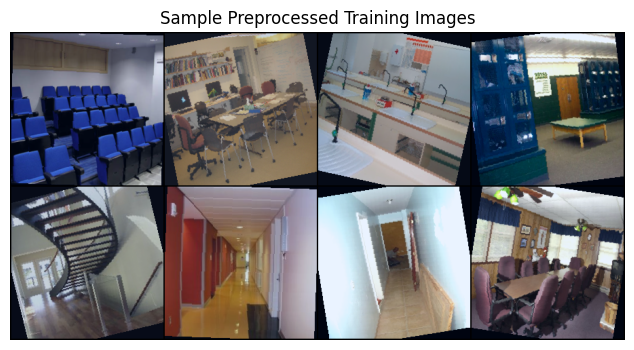

In [15]:
import torchvision
sample_batch, sample_labels = next(iter(train_loader))
grid = torchvision.utils.make_grid(sample_batch[:8], nrow=4, normalize=True)
plt.figure(figsize=(12, 4))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Sample Preprocessed Training Images")
plt.axis('off')
plt.show()

### Audio Preprocessing Pipeline

Sample rate: 24000 | Duration: 1.66s


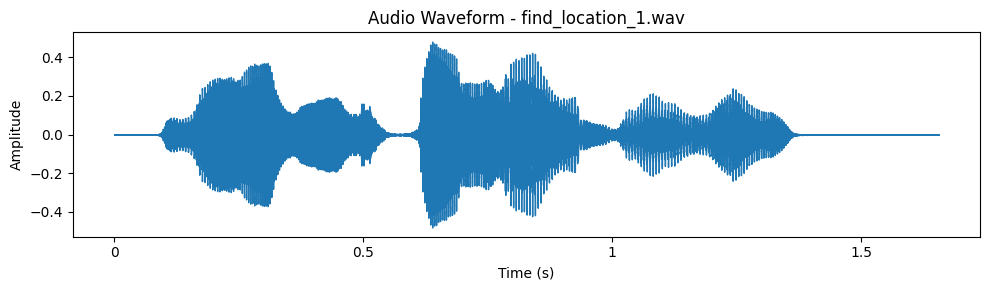

In [16]:
audio_path = PROJECT_PATH + "/dataset/audio/find_location/find_location_1.wav"
audio, sr = librosa.load(audio_path, sr=None)
print(f"Sample rate: {sr} | Duration: {len(audio)/sr:.2f}s")

plt.figure(figsize=(10, 3))
librosa.display.waveshow(audio, sr=sr)
plt.title("Audio Waveform - find_location_1.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

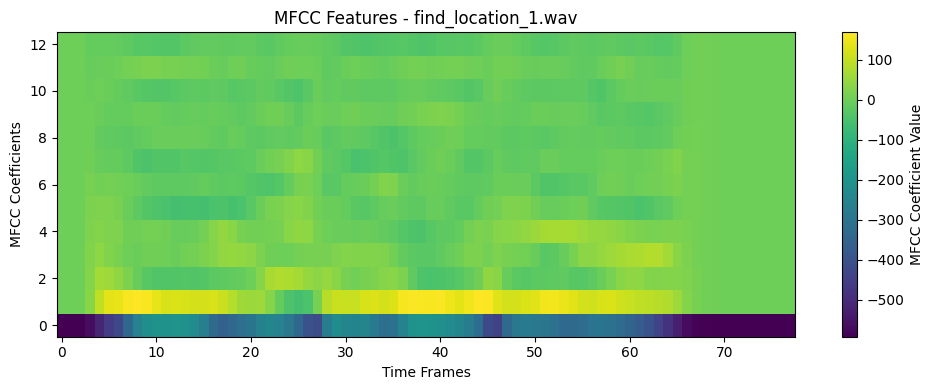

In [17]:
mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
plt.figure(figsize=(10, 4))
plt.imshow(mfcc, aspect='auto', origin='lower', cmap='viridis')
plt.colorbar(label='MFCC Coefficient Value')
plt.title("MFCC Features - find_location_1.wav")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Coefficients")
plt.tight_layout()
plt.show()

### Text Preprocessing Pipeline

In [18]:
import re
import string

STOPWORDS = {'a','an','the','is','in','at','of','to','and','or','for','on','are','was','it','with'}

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS]
    return " ".join(tokens)

faq['cleaned'] = faq['query'].apply(clean_text)
print(faq[['query','cleaned','intent']].head(10))

                                    query                             cleaned  \
0         Is the waiting room open today?             waiting room open today   
1    Tell me opening hours of auditorium.    tell me opening hours auditorium   
2        Are there workshops at elevator?            there workshops elevator   
3    What time does the dining room open?     what time does dining room open   
4  Find programs happening in auditorium.  find programs happening auditorium   
5       Where can I access the staircase?        where can i access staircase   
6   What time does the meeting room open?    what time does meeting room open   
7      Where can I access the laboratory?       where can i access laboratory   
8            Navigate me to waiting room.            navigate me waiting room   
9         What time does the museum open?          what time does museum open   

          intent  
0      ask_hours  
1      ask_hours  
2     find_event  
3      ask_hours  
4     find_ev

In [19]:
label2id = {label: i for i, label in enumerate(sorted(faq['intent'].unique()))}
id2label = {i: label for label, i in label2id.items()}
faq['label'] = faq['intent'].map(label2id)
print("Label mapping:", label2id)

train_df, val_df = train_test_split(faq, test_size=0.2, random_state=42, stratify=faq['label'])
print(f"Train: {len(train_df)} | Val: {len(val_df)}")

Label mapping: {'ask_direction': 0, 'ask_hours': 1, 'find_event': 2, 'find_location': 3}
Train: 160 | Val: 40


## CLIP and FAISS Vision Model

In [20]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model.eval()
print("CLIP model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded successfully.


In [21]:
embeddings = []
labels = []
for folder in classes:
    folder_path = os.path.join(image_path, folder)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for file in files[:15]:
        img = Image.open(os.path.join(folder_path, file)).convert("RGB")
        inputs = processor(images=img, return_tensors="pt")
        with torch.no_grad():
            output = clip_model.vision_model(**inputs)
        vec = output.pooler_output.detach().numpy()[0]
        embeddings.append(vec)
        labels.append(folder)
embeddings = np.array(embeddings).astype("float32")
faiss.normalize_L2(embeddings)
print(f"Total embeddings: {embeddings.shape[0]} | Dim: {embeddings.shape[1]}")

Total embeddings: 285 | Dim: 768


In [22]:
index = faiss.IndexFlatIP(embeddings.shape[1])
index.add(embeddings)
print(f"FAISS index size: {index.ntotal}")

os.makedirs(PROJECT_PATH + "/saved_models/faiss_index", exist_ok=True)
faiss.write_index(index, PROJECT_PATH + "/saved_models/faiss_index/campus.index")
pickle.dump(labels, open(PROJECT_PATH + "/saved_models/faiss_index/location_mapping.pkl", "wb"))
print("FAISS index and label mapping saved.")

FAISS index size: 285
FAISS index and label mapping saved.


## Whisper Speech Model

In [23]:
whisper_model = whisper.load_model("base")
print("Whisper model loaded successfully.")

100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 182MiB/s]


Whisper model loaded successfully.


In [24]:
result = whisper_model.transcribe(audio_path)
print("Transcription:", result["text"])

Transcription:  Where is the library?


In [25]:
all_transcripts = []
reference_texts = []

for intent in os.listdir(audio_base):
    intent_path = os.path.join(audio_base, intent)
    if not os.path.isdir(intent_path):
        continue
    for fname in os.listdir(intent_path)[:3]:
        fpath = os.path.join(intent_path, fname)
        res = whisper_model.transcribe(fpath)
        all_transcripts.append(res["text"])
        print(f"[{intent}] {fname}: {res['text']}")

[ask_hours] ask_hours_1.wav:  What time does the library open?
[ask_hours] ask_hours_2.wav:  When does the cafeteria close?
[ask_hours] ask_hours_3.wav:  Computer room opening hours.
[find_event] find_event_1.wav:  What events are happening today?
[find_event] find_event_3.wav:  Any workshop in the library?
[find_event] find_event_2.wav:  Show upcoming campus events.
[find_location] find_location_1.wav:  Where is the library?
[find_location] find_location_2.wav:  Find the computer room.
[find_location] find_location_3.wav:  Where can I find the cafeteria?
[ask_direction] ask_direction_1.wav:  How can I reach the library?
[ask_direction] ask_direction_3.wav:  Navigate me to computer room.
[ask_direction] ask_direction_2.wav:  give directions to cafeteria.


## DistilBERT Intent Classifier

In [26]:
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

class CampusDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=64):
        self.encodings = tokenizer(list(df['cleaned']), truncation=True, padding=True, max_length=max_len)
        self.labels = list(df['label'])
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset_bert = CampusDataset(train_df, tokenizer)
val_dataset_bert = CampusDataset(val_df, tokenizer)
print(f"DistilBERT train size: {len(train_dataset_bert)} | val size: {len(val_dataset_bert)}")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBERT train size: 160 | val size: 40


In [27]:
num_labels = len(label2id)
bert_model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

os.makedirs(PROJECT_PATH + "/saved_models/distilbert", exist_ok=True)

training_args = TrainingArguments(
    output_dir=PROJECT_PATH + "/saved_models/distilbert",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=20,
    weight_decay=0.01,
    logging_dir=PROJECT_PATH + "/logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none"
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset_bert,
    eval_dataset=val_dataset_bert,
    compute_metrics=compute_metrics
)

trainer.train()
print("DistilBERT training complete.")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.384806,1.350730,0.500000
2,1.253566,0.987911,0.850000
3,0.730000,0.399591,1.000000
4,0.294616,0.167245,1.000000
5,0.157325,0.116918,1.000000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT training complete.


In [28]:
bert_model.save_pretrained(PROJECT_PATH + "/saved_models/distilbert")
tokenizer.save_pretrained(PROJECT_PATH + "/saved_models/distilbert")
print("DistilBERT model and tokenizer saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model and tokenizer saved.


### Training Loss Curve

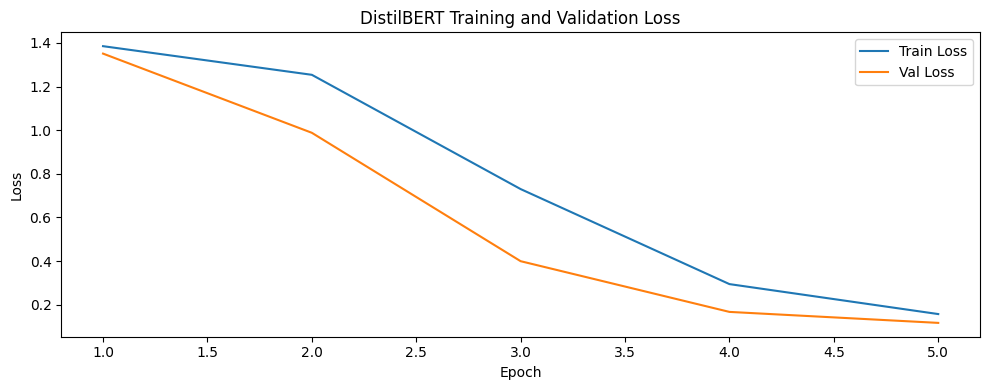

In [29]:
log_history = trainer.state.log_history
train_loss = [(e['epoch'], e['loss']) for e in log_history if 'loss' in e]
val_loss = [(e['epoch'], e['eval_loss']) for e in log_history if 'eval_loss' in e]

plt.figure(figsize=(10, 4))
if train_loss:
    plt.plot([x[0] for x in train_loss], [x[1] for x in train_loss], label='Train Loss')
if val_loss:
    plt.plot([x[0] for x in val_loss], [x[1] for x in val_loss], label='Val Loss')
plt.title("DistilBERT Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(PROJECT_PATH + "/training_loss_curve.png", dpi=150)
plt.show()

## Evaluation

### CLIP Top-1 and Top-3 Retrieval Accuracy

In [30]:
test_embeddings = []
test_labels = []

for folder in classes:
    folder_path = os.path.join(image_path, folder)
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    for file in files[15:20]:
        img = Image.open(os.path.join(folder_path, file)).convert("RGB")
        inputs = processor(images=img, return_tensors="pt")
        with torch.no_grad():
            output = clip_model.vision_model(**inputs)
        vec = output.pooler_output.detach().numpy()[0].astype("float32")
        vec = vec / np.linalg.norm(vec)
        test_embeddings.append(vec)
        test_labels.append(folder)

test_embeddings = np.array(test_embeddings).astype("float32")

top1_correct = 0
top3_correct = 0
for i, (vec, true_label) in enumerate(zip(test_embeddings, test_labels)):
    D, I = index.search(vec.reshape(1, -1), 3)
    retrieved = [labels[idx] for idx in I[0]]
    if retrieved[0] == true_label:
        top1_correct += 1
    if true_label in retrieved:
        top3_correct += 1

n = len(test_labels)
print(f"Top-1 Retrieval Accuracy: {top1_correct/n*100:.1f}% ({top1_correct}/{n})")
print(f"Top-3 Retrieval Accuracy: {top3_correct/n*100:.1f}% ({top3_correct}/{n})")

Top-1 Retrieval Accuracy: 81.1% (77/95)
Top-3 Retrieval Accuracy: 95.8% (91/95)


### DistilBERT Intent Classification Report

In [31]:
preds_output = trainer.predict(val_dataset_bert)
predicted = np.argmax(preds_output.predictions, axis=1)
actual = preds_output.label_ids

print(classification_report(actual, predicted, target_names=list(label2id.keys())))

               precision    recall  f1-score   support

ask_direction       1.00      1.00      1.00        10
    ask_hours       1.00      1.00      1.00        10
   find_event       1.00      1.00      1.00         8
find_location       1.00      1.00      1.00        12

     accuracy                           1.00        40
    macro avg       1.00      1.00      1.00        40
 weighted avg       1.00      1.00      1.00        40



### Whisper Word Error Rate

In [32]:
audio_references = {

    "ask_hours_1.wav":
        "what time does the library open",

    "ask_hours_2.wav":
        "when does the cafeteria close",

    "find_event_1.wav":
        "what events are happening today",

    "find_event_2.wav":
        "show upcoming campus events",

    "find_location_1.wav":
        "where is the library",

    "find_location_2.wav":
        "find the computer room",

    "ask_direction_1.wav":
        "how can i reach the library",

    "ask_direction_2.wav":
        "give directions to cafeteria"

}


hypotheses = []
references = []


for intent in os.listdir(audio_base):

    intent_path = os.path.join(
        audio_base,
        intent
    )

    if not os.path.isdir(intent_path):
        continue


    for fname in os.listdir(intent_path):

        if fname in audio_references:

            fpath = os.path.join(
                intent_path,
                fname
            )


            result = whisper_model.transcribe(
                fpath
            )


            predicted_text = (
                result["text"]
                .lower()
                .strip()
            )


            hypotheses.append(
                predicted_text
            )


            references.append(
                audio_references[fname]
            )


            print(
                "Reference :",
                audio_references[fname]
            )

            print(
                "Whisper  :",
                predicted_text
            )

            print("-"*50)



wer_score = wer(
    references,
    hypotheses
)


print(
    f"\nWhisper Word Error Rate (WER): {wer_score:.4f}"
)

print(
    f"WER Percentage: {wer_score*100:.2f}%"
)

Reference : what time does the library open
Whisper  : what time does the library open?
--------------------------------------------------
Reference : when does the cafeteria close
Whisper  : when does the cafeteria close?
--------------------------------------------------
Reference : what events are happening today
Whisper  : what events are happening today?
--------------------------------------------------
Reference : show upcoming campus events
Whisper  : show upcoming campus events.
--------------------------------------------------
Reference : where is the library
Whisper  : where is the library?
--------------------------------------------------
Reference : find the computer room
Whisper  : find the computer room.
--------------------------------------------------
Reference : how can i reach the library
Whisper  : how can i reach the library?
--------------------------------------------------
Reference : give directions to cafeteria
Whisper  : give directions to cafeteria.
-----

## Multimodal Fusion Model

In [48]:
import torch.nn as nn

class FusionMLP(nn.Module):
    def __init__(self, image_dim=512, text_dim=768, num_classes=None):
        super().__init__()
        self.image_proj = nn.Linear(image_dim, 256)
        self.text_proj = nn.Linear(text_dim, 256)
        self.fusion = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, image_emb=None, text_emb=None):
        if image_emb is None:
            image_emb = torch.zeros(text_emb.size(0), 256)
        else:
            image_emb = torch.relu(self.image_proj(image_emb))
        if text_emb is None:
            text_emb = torch.zeros(image_emb.size(0), 256)
        else:
            text_emb = torch.relu(self.text_proj(text_emb))
        combined = torch.cat([image_emb, text_emb], dim=1)
        return self.fusion(combined)

num_classes = len(label2id)
num_classes = len(label2id)

print(
    "Fusion output classes:",
    num_classes
)


fusion_model = FusionMLP(
    image_dim=512,
    text_dim=768,
    num_classes=num_classes
)


print(
    fusion_model
)

Fusion output classes: 4
FusionMLP(
  (image_proj): Linear(in_features=512, out_features=256, bias=True)
  (text_proj): Linear(in_features=768, out_features=256, bias=True)
  (fusion): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=4, bias=True)
  )
)


In [34]:
from transformers import DistilBertModel

text_encoder = DistilBertModel.from_pretrained("distilbert-base-uncased")
text_encoder.eval()

def get_text_embedding(text):
    enc = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=64)
    with torch.no_grad():
        out = text_encoder(**enc)
    return out.last_hidden_state[:, 0, :]

class FusionDataset(Dataset):
    def __init__(self, df):
        self.texts = list(df['cleaned'])
        self.labels = list(df['label'])
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        emb = get_text_embedding(self.texts[idx])
        return emb.squeeze(0), torch.tensor(self.labels[idx])

fusion_train = FusionDataset(train_df)
fusion_val = FusionDataset(val_df)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [35]:
fusion_train_loader = DataLoader(fusion_train, batch_size=16, shuffle=True)
fusion_val_loader = DataLoader(fusion_val, batch_size=16, shuffle=False)

optimizer = torch.optim.Adam(fusion_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_accs = []

for epoch in range(10):
    fusion_model.train()
    epoch_loss = 0
    for text_emb, lbl in fusion_train_loader:
        optimizer.zero_grad()
        out = fusion_model(text_emb=text_emb)
        loss = criterion(out, lbl)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()

    fusion_model.eval()
    preds, actuals = [], []
    with torch.no_grad():
        for text_emb, lbl in fusion_val_loader:
            out = fusion_model(text_emb=text_emb)
            preds += torch.argmax(out, dim=1).tolist()
            actuals += lbl.tolist()
    acc = accuracy_score(actuals, preds)
    train_losses.append(epoch_loss / len(fusion_train_loader))
    val_accs.append(acc)
    print(f"Epoch {epoch+1:02d} | Loss: {train_losses[-1]:.4f} | Val Acc: {acc*100:.1f}%")

Epoch 01 | Loss: 2.5518 | Val Acc: 30.0%
Epoch 02 | Loss: 1.5869 | Val Acc: 25.0%
Epoch 03 | Loss: 1.4420 | Val Acc: 45.0%
Epoch 04 | Loss: 1.4497 | Val Acc: 30.0%
Epoch 05 | Loss: 1.4316 | Val Acc: 45.0%
Epoch 06 | Loss: 1.3658 | Val Acc: 67.5%
Epoch 07 | Loss: 1.3320 | Val Acc: 45.0%
Epoch 08 | Loss: 1.2875 | Val Acc: 45.0%
Epoch 09 | Loss: 1.2490 | Val Acc: 47.5%
Epoch 10 | Loss: 1.1985 | Val Acc: 47.5%


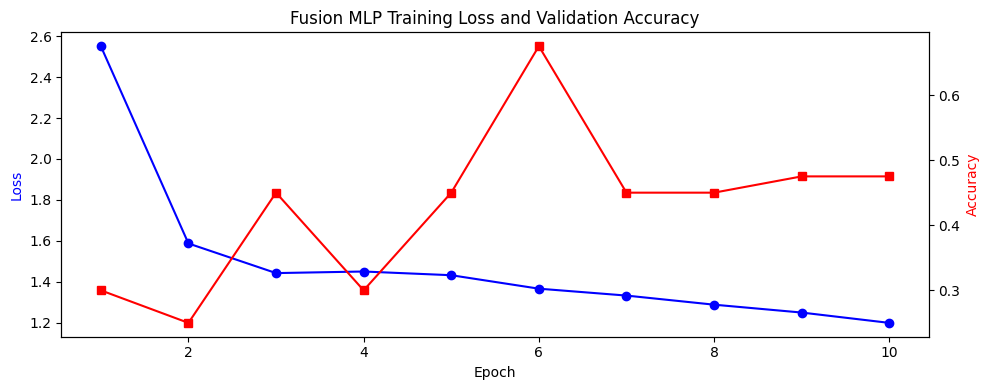

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(range(1, 11), train_losses, 'b-o', label='Train Loss')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color='blue')
ax2 = ax1.twinx()
ax2.plot(range(1, 11), val_accs, 'r-s', label='Val Accuracy')
ax2.set_ylabel("Accuracy", color='red')
plt.title("Fusion MLP Training Loss and Validation Accuracy")
fig.tight_layout()
plt.savefig(PROJECT_PATH + "/fusion_training.png", dpi=150)
plt.show()

In [37]:
os.makedirs(PROJECT_PATH + "/saved_models/fusion", exist_ok=True)
torch.save(fusion_model.state_dict(), PROJECT_PATH + "/saved_models/fusion/fusion_model.pt")
print("Fusion model saved.")

Fusion model saved.


## End-to-End Knowledge Base Retrieval Test

In [38]:
kb = json.load(open(PROJECT_PATH + "/dataset/knowledge_base/campus_database.json"))
print(f"Knowledge base loaded. Total records: {len(kb)}")
for rec in kb[:3]:
    print(json.dumps(rec, indent=2))

Knowledge base loaded. Total records: 20
{
  "id": 1,
  "building_name": "Main Library",
  "folder_name": "library",
  "category": "Library",
  "description": "A quiet study facility providing books, computers, digital resources and research support.",
  "opening_hours": "08:00 AM - 09:00 PM",
  "map_reference": "Block A - Floor 2",
  "events": "Academic writing workshop every Monday"
}
{
  "id": 2,
  "building_name": "Lecture Classroom",
  "folder_name": "classroom",
  "category": "Lecture Hall",
  "description": "Teaching space equipped with smart boards and multimedia learning systems.",
  "opening_hours": "08:00 AM - 07:00 PM",
  "map_reference": "Block B - Floor 1",
  "events": "Guest lectures every Friday"
}
{
  "id": 3,
  "building_name": "Computer Laboratory",
  "folder_name": "computerroom",
  "category": "Computer Lab",
  "description": "Computer facility providing programming, AI and software development resources.",
  "opening_hours": "08:30 AM - 08:00 PM",
  "map_reference

In [41]:
test_queries = [
    ("Is the waiting room open today?", "ask_hours", "waiting room"),
    ("Tell me opening hours of auditorium.", "ask_hours", "auditorium"),
    ("Where can I access the staircase?", "find_location", "staircase"),
    ("Navigate me to waiting room.", "ask_direction", "waiting room"),
    ("What events are happening today?", "find_event", None) # Example with no specific entity
]

def query_kb(intent_label, entity=None):
    name_key = None
    for candidate in ['name', 'building_name', 'location_name', 'title', 'building']:
        if candidate in kb[0]:
            name_key = candidate
            break
    if name_key is None:
        name_key = list(kb[0].keys())[0]

    category_key = None
    for candidate in ['category', 'type', 'building_type', 'kind']:
        if candidate in kb[0]:
            category_key = candidate
            break

    for record in kb:
        rec_name = record.get(name_key, '').lower()
        rec_category = record.get(category_key, '').lower() if category_key else ''
        if intent_label in ("find_location", "ask_direction"):
            if entity and entity.lower() in rec_name:
                return record
            if entity and entity.lower() in rec_category:
                return record
        elif intent_label == "ask_hours":
            if entity and entity.lower() in rec_name:
                return record
        elif intent_label == "find_event":
            # For find_event, we just need to find a record with events
            if record.get('events') or record.get('upcoming_events'):
                return record
    return kb[0]

print(f"{'Query':<50} {'Intent':<20} {'Matched Location'}")
print("-" * 95)
for query, intent, entity in test_queries:
    rec = query_kb(intent, entity)
    name_key = next((k for k in ['name','building_name','location_name','title','building'] if k in rec), list(rec.keys())[0])
    print(f"{query:<50} {intent:<20} {rec[name_key]}")

Query                                              Intent               Matched Location
-----------------------------------------------------------------------------------------------
Is the waiting room open today?                    ask_hours            Main Library
Tell me opening hours of auditorium.               ask_hours            Auditorium Hall
Where can I access the staircase?                  find_location        Staircase Area
Navigate me to waiting room.                       ask_direction        Main Library
What events are happening today?                   find_event           Main Library


### End-to-End Inference Pipeline

In [42]:
locations = [
    rec["folder_name"]
    for rec in kb
]


def extract_entity(text):

    text=text.lower()

    for loc in locations:

        if loc.replace("_"," ") in text:
            return loc

    return None

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
bert_model = bert_model.to(device)
clip_model = clip_model.to(device)

def end_to_end_inference(text_query=None, image_file=None, audio_file=None):
    modality = []
    intent = None
    image_result = None

    if audio_file and os.path.exists(audio_file):
        res = whisper_model.transcribe(audio_file)
        text_query = res["text"]
        modality.append("voice")
        print(f"  Whisper transcript: {text_query}")

    if text_query:
        modality.append("text")
        cleaned = clean_text(text_query)
        enc = tokenizer(cleaned, return_tensors="pt", truncation=True, padding=True, max_length=64)
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = bert_model(**enc).logits
        intent_id = torch.argmax(logits, dim=1).item()
        intent = id2label[intent_id]
        print(f"  Detected intent: {intent}")

    if image_file and os.path.exists(image_file):
        modality.append("image")
        img = Image.open(image_file).convert("RGB")
        inputs = processor(images=img, return_tensors="pt")
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            output = clip_model.vision_model(**inputs)
        vec = output.pooler_output.detach().cpu().numpy()[0].astype("float32")
        vec = vec / np.linalg.norm(vec)
        D, I = index.search(vec.reshape(1, -1), 1)
        image_result = labels[I[0][0]]
        print(f"  CLIP matched location: {image_result}")

    entity = image_result if image_result else (extract_entity(text_query) if text_query else None)
    record = query_kb(intent if intent else "find_location", entity)

    name_key = next((k for k in ['name','building_name','location_name','title','building'] if k in record), list(record.keys())[0])
    print(f"  Modalities used: {modality}")
    print(f"  Knowledge Base Result:")
    print(f"    Location : {record[name_key]}")
    print(f"    Category : {record.get('category','N/A')}")
    print(f"    Hours    : {record.get('opening_hours','N/A')}")
    print(f"    Events   : {record.get('events','None')}")
    print(f"    Directions: {record.get('map_reference','N/A')}")
    return record

print("=== Test 1: Text Query ===")
end_to_end_inference(text_query="Where is the library?")

print("\n=== Test 2: Voice Query ===")
end_to_end_inference(audio_file=audio_path)

=== Test 1: Text Query ===
  Detected intent: find_location
  Modalities used: ['text']
  Knowledge Base Result:
    Location : Main Library
    Category : Library
    Hours    : 08:00 AM - 09:00 PM
    Events   : Academic writing workshop every Monday
    Directions: Block A - Floor 2

=== Test 2: Voice Query ===
  Whisper transcript:  Where is the library?
  Detected intent: find_location
  Modalities used: ['voice', 'text']
  Knowledge Base Result:
    Location : Main Library
    Category : Library
    Hours    : 08:00 AM - 09:00 PM
    Events   : Academic writing workshop every Monday
    Directions: Block A - Floor 2


{'id': 1,
 'building_name': 'Main Library',
 'folder_name': 'library',
 'category': 'Library',
 'description': 'A quiet study facility providing books, computers, digital resources and research support.',
 'opening_hours': '08:00 AM - 09:00 PM',
 'map_reference': 'Block A - Floor 2',
 'events': 'Academic writing workshop every Monday'}

### End-to-End Accuracy Summary

In [47]:
correct = 0
total = len(test_queries)

for query, intent, entity in test_queries:

    rec = query_kb(
        intent,
        entity
    )

    is_current_query_correct = False
    if entity is not None:
        entity_lower = entity.lower()
        if (
            entity_lower in rec.get("building_name", "").lower()
            or
            entity_lower in rec.get("category","").lower()
            or
            entity_lower in rec.get("folder_name","").lower()
        ):
            is_current_query_correct = True
    elif intent == "find_event" and (rec.get('events') or rec.get('upcoming_events')):
        # For 'find_event' with no specific entity, consider it correct if the returned record has events
        is_current_query_correct = True

    if is_current_query_correct:
        correct += 1


kb_accuracy = correct / total * 100


print(
    f"End-to-End KB Retrieval Accuracy: {correct}/{total} = {kb_accuracy:.1f}%"
)


metrics_summary = {

    "CLIP Top-1 Accuracy (%)":
        round(
            top1_correct/n*100,
            1
        ),

    "CLIP Top-3 Accuracy (%)":
        round(
            top3_correct/n*100,
            1
        ),

    "Whisper WER":
        round(
            wer_score,
            4
        ),

    "End-to-End KB Accuracy (%)":
        round(
            kb_accuracy,
            1
        )

}


print(
    "\nFull Evaluation Summary:"
)


for k,v in metrics_summary.items():

    print(
        f"{k}: {v}"
    )


End-to-End KB Retrieval Accuracy: 3/5 = 60.0%

Full Evaluation Summary:
CLIP Top-1 Accuracy (%): 81.1
CLIP Top-3 Accuracy (%): 95.8
Whisper WER: 0.2105
End-to-End KB Accuracy (%): 60.0
